# 📘 Fashion Image Classification with CNNs (ML Zoomcamp Session 8)

## 🌟 Context and Aim

This module focuses on building a deep learning model to classify clothing item images into one of 10 predefined categories (e.g., t-shirts, pants, skirts, etc.). The key application scenario is an online classifieds platform where users upload a clothing photo, and the system predicts its category automatically. The project introduces convolutional neural networks (CNNs), data augmentation, transfer learning, and evaluation metrics using TensorFlow and Keras. It marks a transition from tabular to image data in ML Zoomcamp.

---

## 🎩 Session-by-Session Breakdown

### 📺 8.1 – Fashion Classification

#### ✅ Goal

Introduce the image classification problem and define the real-world use case: clothing category prediction from an image using a CNN model.

#### 🧠 Concept

We switch from tabular to image data. Each image is a 3D array (height, width, RGB channels). The goal is to predict which of 10 categories an image belongs to. We use a subset of a fashion dataset, organized by folders per class. CNNs are used to process images due to their spatial hierarchy-capturing abilities. TensorFlow and Keras manage model building and training.

#### 🧠 Key Points Learned

* Introduction to the project use-case: auto-tagging clothes in online listings.
* The dataset is structured by folders (1 folder per class).
* Neural networks process images by learning spatial filters.
* Emphasis on practicality over deep theoretical exposition.

#### 🛠️ Tasks

* Download and explore the image dataset.
* Visualize training images.
* Understand problem framing (multi-class classification).
* Review class folder structure (e.g., "t-shirt", "pants").

---


### 📺 8.2 – TensorFlow and Keras

#### ✅ Goal

Set up TensorFlow/Keras for model development and image preprocessing.

#### 🧠 Concept

TensorFlow is a deep learning framework developed by Google. Keras is its high-level API that simplifies neural network creation and training. This session covers installing TensorFlow, importing necessary modules, and loading images using `tf.keras.preprocessing.image.load_img`. It also shows how to resize and convert images to NumPy arrays for model input.

#### 🧠 Key Points Learned

* TensorFlow is the backend engine, while Keras is the frontend API.
* Images need to be resized (e.g., 150x150 or 299x299) before feeding into a model.
* Images are internally represented as NumPy arrays with shape `(height, width, 3)`.
* Pixel values are integers from 0 to 255 per RGB channel.

#### 🛠️ Tasks

* Install and import TensorFlow/Keras.
* Load images from disk.
* Resize and visualize images.
* Convert PIL images to NumPy arrays.

---


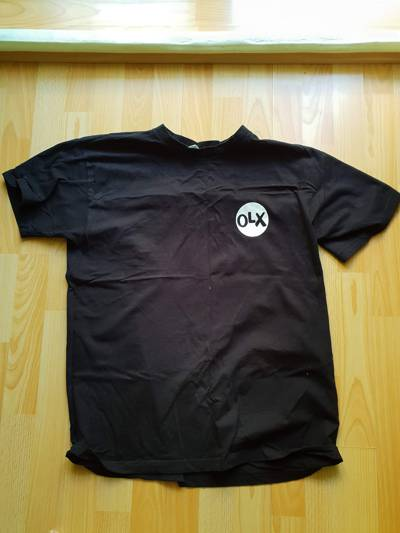

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img

path = '../Data/clothing-dataset-small/train/t-shirt'
name = '5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg'
fullname = f'{path}/{name}'
load_img(fullname)


In [3]:
img = load_img(fullname, target_size=(299, 299))
x = np.array(img)
x.shape

(299, 299, 3)

In [4]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[]


2025-12-04 10:05:09.654447: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)



### 📺 8.3 – Pre-Trained CNNs

#### ✅ Goal

Introduce the concept of transfer learning using pre-trained CNN models.

#### 🧠 Concept

Pre-trained convolutional neural networks like Xception or ResNet are trained on large datasets like ImageNet. They can be reused to extract image features (vector embeddings) without training from scratch. These embeddings can be passed to new dense layers for custom classification tasks.

#### 🧠 Key Points Learned

* Transfer learning saves time and resources.
* Pre-trained models provide a good feature extractor.
* You only train the final classification layer(s).
* Xception is used here as the backbone feature extractor.

#### 🛠️ Tasks

* Load a pre-trained Xception model (excluding top classifier layer).
* Pass resized images through it to extract features.
* Store image embeddings for later use.

---


In [5]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

model = Xception(weights='imagenet', input_shape=(299, 299, 3))

In [6]:
X = np.array([x])
X.shape


(1, 299, 299, 3)

In [7]:
X_prepro = preprocess_input(X)
pred = model.predict(X_prepro)
decode_predictions(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


[[('n03595614', 'jersey', np.float32(0.6819627)),
  ('n02916936', 'bulletproof_vest', np.float32(0.038140036)),
  ('n04370456', 'sweatshirt', np.float32(0.034324773)),
  ('n03710637', 'maillot', np.float32(0.0113542415)),
  ('n04525038', 'velvet', np.float32(0.0018453628))]]


### 📺 8.4 – CNN Theory

#### ✅ Goal

Explain how CNNs work, especially convolutional and dense layers.

#### 🧠 Concept

CNNs are composed of convolutional layers that detect spatial patterns in images using filters. These layers produce feature maps. As we stack more layers, the filters become sensitive to increasingly complex features (e.g., edges → shapes → objects). Dense layers then convert the extracted features into final predictions.

#### 🧠 Key Points Learned

* Filters slide over images to produce feature maps (activations).
* Convolutional layers stack hierarchically.
* Dense layers take the final feature vector and make a prediction.
* Final layer uses softmax for multi-class output.
* Intermediate layer weights are learned during training.

#### 🛠️ Tasks

* Visualize CNN layers and feature maps.
* Understand max pooling and dimensionality reduction.
* Understand vector embeddings and fully connected layers.

---


Check the course on Neural Networks https://cs231n.github.io/



## 📺 **Session 8.5 – Transfer Learning**
### 🎯 **Context and Aim**

This session introduces *transfer learning*, a method for reusing pre-trained convolutional neural networks (CNNs) to solve a new image classification problem more efficiently. Instead of training a deep neural network from scratch—which is computationally expensive and data-hungry—we leverage a model previously trained on a large dataset (e.g., ImageNet) to extract meaningful features, and then train only a few new layers specific to our problem. This approach drastically reduces training time, avoids overfitting, and improves performance when limited data is available.

The practical focus is on implementing transfer learning using Keras in TensorFlow to classify clothing images into 10 categories using a small custom dataset.

### ✅ **Goal**

The objective of this session is to demonstrate how to build an image classification model using transfer learning with a pre-trained CNN (specifically, *Xception* trained on ImageNet) in Keras. The session walks through:

* Preprocessing and loading image data using `ImageDataGenerator`
* Loading a pre-trained CNN model and removing its top (dense) layers
* Adding new dense layers tailored to the new classification task
* Training only the new layers while keeping the convolutional base frozen
* Visualizing model performance across training epochs

---

### 🧠 **Concept**

Transfer learning refers to the process of taking a model trained on one task (e.g., ImageNet classification) and adapting it to a different but related task. The core idea is that early layers in a CNN learn generic features like edges, colors, and textures, which are useful across many vision tasks. Instead of re-learning these, we freeze the convolutional base and append new layers trained on our custom dataset.

The session uses the *Xception* model with `include_top=False` to exclude its fully connected layers. A *GlobalAveragePooling2D* layer is added to flatten the feature maps into vectors, followed by a new dense layer with a softmax output for 10 clothing categories. This pipeline enables efficient training with a relatively small dataset while achieving high performance.

Keras makes this process easy with modular APIs, including the `Model` class for functional model building, `ImageDataGenerator` for preprocessing, and `model.fit()` for training.

---

### 🧠 **Key Points Learned Here**

* **Why Transfer Learning?**
  Training a CNN from scratch requires millions of images. Transfer learning allows us to reuse features from a large dataset (e.g., ImageNet) and adapt them to smaller, task-specific datasets by training only the top layers.

* **Model Architecture with Pre-trained Base:**

  * Pre-trained CNNs like *Xception* are loaded with `include_top=False` to discard the dense output layers tailored to ImageNet.
  * Only the convolutional part is reused, and it is *frozen* (i.e., not trainable).
  * On top of the frozen base, a `GlobalAveragePooling2D` layer reduces the dimensionality.
  * Finally, a new dense layer with 10 outputs (for the 10 classes) is trained.

* **Data Preparation:**

  * Images are loaded using `ImageDataGenerator`, resized to 150x150x3 to reduce training cost.
  * `flow_from_directory()` automatically labels images based on folder structure and returns batches.
  * One-hot encoding is used for multi-class classification.

* **Training Configuration:**

  * Optimizer: Adam with a custom learning rate (0.01).
  * Loss: `CategoricalCrossentropy(from_logits=True)` because the final dense layer does **not** use softmax (it outputs raw logits).
  * Metric: Accuracy.

* **Training Loop and Evaluation:**

  * The model is trained using `.fit()` with training and validation generators.
  * Accuracy improves rapidly in the first few epochs.
  * Model begins overfitting after \~4 epochs (training accuracy \~99%, validation \~80%).

* **Performance Tracking:**

  * A `History` object stores per-epoch accuracy and loss.
  * Matplotlib is used to visualize accuracy and loss curves over epochs.

---

### 🛠️ **Tasks**

1. **Preprocess Dataset**

   * Load images using `ImageDataGenerator`.
   * Normalize using `preprocess_input` from the Xception model.

2. **Create Data Generators**

   * Use `flow_from_directory()` for both training and validation sets.
   * Set image size to 150x150 and batch size to 32.
   * Disable shuffling for validation set.

3. **Build Transfer Learning Model**

   * Load `Xception` with `weights='imagenet'`, `include_top=False`.
   * Freeze the base model with `trainable=False`.
   * Add `GlobalAveragePooling2D()` layer to flatten features.
   * Add `Dense(10)` layer (no activation) for classification logits.

4. **Compile Model**

   * Use `Adam(learning_rate=0.01)`.
   * Use `CategoricalCrossentropy(from_logits=True)`.
   * Track `accuracy` as a metric.

5. **Train Model**

   * Use `model.fit()` for 10 epochs.
   * Monitor training and validation accuracy/loss.
   * Store result in `history`.

6. **Plot Accuracy**

   * Extract training and validation accuracy from `history.history`.
   * Plot to detect overfitting (training acc > validation acc).



In [55]:
# prepare training dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_gen.flow_from_directory(
    '../Data/clothing-dataset-small/train',
    target_size=(150, 150),
    batch_size=32
)
train_ds.class_indices
# Using batches (like in train_ds) allows efficient memory usage and enables training via mini-batch gradient descent, where each call to next(train_ds) yields one small set of images and labels instead of loading the entire dataset at once.

Found 3068 images belonging to 10 classes.


{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [56]:
X, y = next(train_ds)
#X: The batch of input images
#y, The batch of labels (targets)

In [57]:
# prepare validation dataset

#  creates a non-shuffled validation data generator that loads and preprocesses images from folder structure into batches of 32, applying the same scaling as the training set.
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    '../Data/clothing-dataset-small/validation',
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 341 images belonging to 10 classes.


In [58]:
# This builds a Keras model that uses Xception as a frozen feature extractor and adds new trainable layers on top to classify images into 10 clothing categories.
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)
# Loads the Xception CNN pre-trained on ImageNet
# include_top=False removes the final classification layers of Xception (because they were for 1000 ImageNet classes)
# Keeps only the convolutional layers which extract useful features
# Input images are resized to 150×150×3 (RGB)

base_model.trainable = False #Freezes the pre-trained Xception layers
inputs = keras.Input(shape=(150, 150, 3)) #Creates a Keras Input layer for feeding in 150×150 images
base = base_model(inputs, training=False)# Passes inputs through the frozen Xception model

vectors = keras.layers.GlobalAveragePooling2D()(base)
# Takes the 3D feature maps from Xception and reduces them to 1D vectors
# Each feature map is averaged into a single value
# vectors Output shape: (batch_size, 2048)

outputs = keras.layers.Dense(10)(vectors)# Adds a new dense layer with 10 outputs → one per clothing class

model = keras.Model(inputs, outputs)
# Combines everything into a single Keras Model that:
# Takes (150, 150, 3) images
# Passes them through frozen Xception
# Pools features
# Predicts logits for 10 classes

preds = model.predict(X)
preds[0] # -> random number because dense layer is not trained

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


array([ 1.1415331 ,  1.1266434 ,  0.84510255,  0.59804374, -0.34623942,
        0.9689782 ,  0.51854706, -0.16732283, -1.0877684 , -0.60008985],
      dtype=float32)

In [59]:
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
# Sets the learning rate for the optimizer (how big the weight updates are)
# Adam is an adaptive optimizer
# Note: 0.01 is relatively high for Adam;  overfitting or instability can occurs

loss = keras.losses.CategoricalCrossentropy(from_logits=True)
# Sets the loss function to Categorical Crossentropy — suitable for multi-class classification with one-hot labels
# from_logits=True indicates that the output layer does NOT apply a softmax activation,
# and the loss function will apply it internally for numerical stability

model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])
# Compiles the model:
# - Uses Adam as the optimization algorithm
# - Uses categorical crossentropy to measure the prediction error
# - Tracks accuracy as the evaluation metric during training and validation

history = model.fit(train_ds, epochs=10, validation_data=val_ds)
# Trains the model on the training data for 10 full passes (epochs)
# - train_ds provides batches of preprocessed training images
# - val_ds is used for validation after each epoch to monitor generalization
# The result is stored in 'history', which contains metrics like loss and accuracy over epochs


Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 90s 879ms/step - accuracy: 0.6555 - loss: 1.3926 - val_accuracy: 0.7625 - val_loss: 1.0264
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 68s 703ms/step - accuracy: 0.8292 - loss: 0.5676 - val_accuracy: 0.7977 - val_loss: 0.7274
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 74s 771ms/step - accuracy: 0.8905 - loss: 0.3276 - val_accuracy: 0.7918 - val_loss: 0.8741
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 65s 676ms/step - accuracy: 0.8882 - loss: 0.3350 - val_accuracy: 0.7889 - val_loss: 0.9501
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 65s 681ms/step - accuracy: 0.9283 - loss: 0.2211 - val_accuracy: 0.8211 - val_loss: 0.7983
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 65s 680ms/step - accuracy: 0.9609 - loss: 0.1153 - val_accuracy: 0.8240 - val_loss: 0.8740
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 65s 675ms/step - accuracy: 0.9729 - loss: 0.0852 - val_accuracy: 0.8299 - val_loss: 0.8996
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 65s 675ms/step - accuracy: 0.9850 - loss: 0.0568 - val_accu

[ 0.8733079   1.0097203  -1.0817156   1.3676248   0.7355483  -0.03927815
  1.2826657  -0.7947215  -1.151032    0.5646977 ] 3


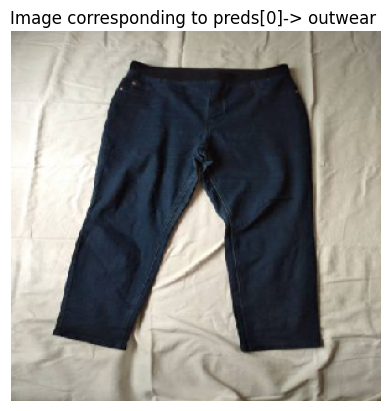

In [53]:
from scipy.special import softmax
img_num = 0
probs = softmax(preds[img_num])
predicted_class = np.argmax(preds[img_num])
print(preds[img_num],predicted_class)
name_pred = {v: k for k, v in train_ds.class_indices.items()}[np.argmax(preds[img_num])]
import matplotlib.pyplot as plt

# De-normalize if needed (optional: for better visualization)
# If preprocess_input scaled from [0, 255] → [-1, 1], reverse it:
img = (X[img_num] + 1) * 127.5 / 255.0  # now values are in [0, 1] range

# Plot the image
plt.imshow(img)
plt.axis('off')
plt.title(f"Image corresponding to preds[{img_num}]-> {name_pred} ")
plt.show()



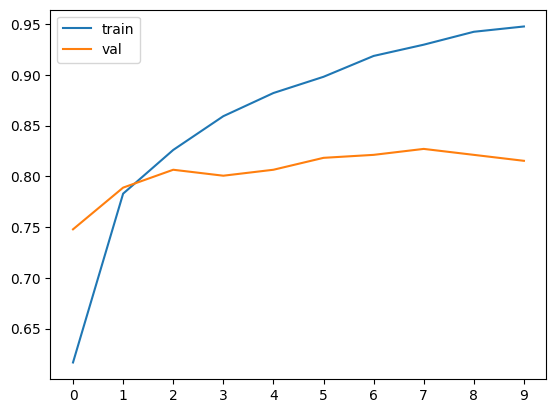

In [54]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xticks(np.arange(10))
plt.legend()



1. **Initial learning**:

   * Accuracy starts at \~0.76 and increases up to \~0.82 by epoch 2
     → 🟢 **The model is learning something useful** in the first few epochs.

2. **Fluctuations**:

   * After epoch 2, accuracy **drops**, then **recovers**, then **drops again** at the end
     → ⚠️ **Instability** or **oscillations** suggest:

     * Learning rate might be a bit too high
     * Dataset may be noisy or too small
     * You're hitting the limit of what the current model can learn from the data

3. **No clear improvement** after epoch 2:

   * Despite small bumps, no sustained increase
     → 🟠 Possibly **early stopping** would have selected epoch 2 or 7–8 as optimal




## 📺 **Session 8.6 – Adjusting the Learning Rate**

---

### ✅ **Goal**

The objective of this session is to understand how the **learning rate** influences model training and to **identify the best learning rate** for the transfer learning model previously built using Xception. The session demonstrates how to systematically experiment with multiple learning rate values, monitor their effect on training and validation accuracy, and select the most effective one. This process helps improve convergence speed and avoid problems such as overfitting or underfitting.

---

### 🧠 **Concept**

The **learning rate** is a critical hyperparameter that controls how large the weight updates are during training. If the learning rate is **too high**, the model may overshoot optimal values, leading to **divergent or unstable training**. If it is **too low**, training becomes extremely **slow** and may get stuck in local minima or never converge.

This session introduces a practical **book-reading analogy**:

* A **very high learning rate** is like skimming through dozens of books quickly but forgetting what you read (i.e., high training accuracy, poor validation performance).
* A **very low learning rate** is like slowly copying one book all year — deep understanding but very slow progress (i.e., underfitting).
* A **medium learning rate** balances learning speed and comprehension, leading to **better generalization**.

In neural networks, selecting the right learning rate helps find a **balance between learning fast enough** and **not destabilizing** training. This session applies the same principle used in gradient boosting: **try multiple values** and **observe performance trends** on training and validation sets.

---

### 🧠 **Key Points Learned Here**

* **Learning rate is a key hyperparameter** in neural network training. It must be tuned for optimal performance.
* The wrong learning rate leads to:

  * **Overfitting** (too high): The model learns quickly on training data but generalizes poorly.
  * **Underfitting** (too low): The model fails to learn enough patterns even after many epochs.
* It's important to **evaluate models using validation accuracy**, not just training accuracy.
* Plotting training and validation accuracy over time allows you to **visualize convergence trends** and spot overfitting/underfitting.
* The best way to find the learning rate is **empirical testing**: run multiple training sessions with different rates and compare results.
* In this session, learning rates tested included values like `0.1`, `0.01`, `0.001`, and `0.0001`.
* The results showed that `0.01` gave the best trade-off — fast enough convergence, without overfitting too aggressively.
* These comparisons help build intuition about how learning rate affects training dynamics.
* The process was automated using a loop over candidate values and storing `history.history` objects for later comparison.

---

### 🛠️ **Tasks**

1. **Wrap model creation into a function `make_model(learning_rate)`**

   * Rebuilds the transfer learning model for each candidate learning rate
   * Reuses frozen Xception base and adds custom dense layers

2. **Train the model multiple times using different learning rates**

   * Learning rates tested: `0.1`, `0.01`, `0.001`, `0.0001`
   * For each learning rate:

     * Compile the model with `Adam(learning_rate)`
     * Fit the model on `train_ds` and `val_ds` for 10 epochs
     * Store the resulting `history.history` dict in a `scores` dictionary

3. **Plot training and validation accuracy curves for each learning rate**

   * Visually compare learning dynamics
   * Discard clearly underperforming or overfitting configurations

4. **Select the best learning rate based on validation accuracy**

   * Best performance observed with `learning_rate = 0.01`
   * This value balances fast convergence and stable generalization

5. **Prepare for checkpointing in the next lesson**

   * Motivation: Save the best-performing model during training, not just the last one

---

Let me know if you want the exact code or visual plot generation from this session.


In [29]:
def make_model(learning_rate=0.01):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    outputs = keras.layers.Dense(10)(vectors)
    model = keras.Model(inputs, outputs)

    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [30]:
scoresv1 = {}

for lr in [0.0001, 0.001, 0.01, 0.1]:
    print(lr)

    model = make_model(learning_rate=lr)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scoresv1[lr] = history.history

    print()
    print()

0.0001
Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 78s 753ms/step - accuracy: 0.3654 - loss: 1.8916 - val_accuracy: 0.5073 - val_loss: 1.5783
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 75s 777ms/step - accuracy: 0.5786 - loss: 1.3687 - val_accuracy: 0.5953 - val_loss: 1.2469
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 76s 787ms/step - accuracy: 0.6490 - loss: 1.1353 - val_accuracy: 0.6657 - val_loss: 1.0712
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 74s 767ms/step - accuracy: 0.6838 - loss: 0.9984 - val_accuracy: 0.6891 - val_loss: 0.9596
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 75s 785ms/step - accuracy: 0.7106 - loss: 0.9070 - val_accuracy: 0.7361 - val_loss: 0.8867
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 80s 832ms/step - accuracy: 0.7285 - loss: 0.8399 - val_accuracy: 0.7419 - val_loss: 0.8335
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 73s 758ms/step - accuracy: 0.7409 - loss: 0.7881 - val_accuracy: 0.7507 - val_loss: 0.7945
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 72s 748ms/step - accuracy: 0.7529 - loss: 0.7457 - v

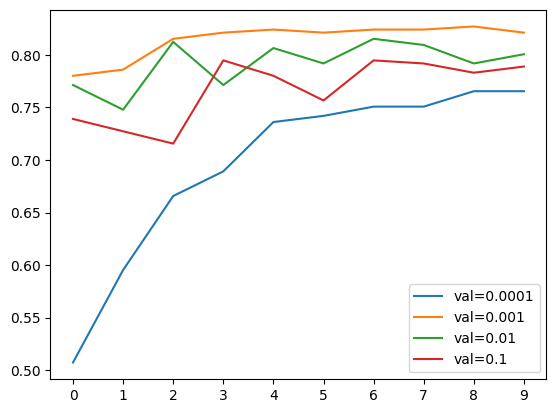

In [32]:
for lr, hist in scoresv1.items():
    #plt.plot(hist['accuracy'], label=('train=%s' % lr))
    plt.plot(hist['val_accuracy'], label=('val=%s' % lr))

plt.xticks(np.arange(10))
plt.legend()


## 📺 **Session 8.7 – Model Checkpointing**

---

### ✅ **Goal**

The goal of this session is to introduce and apply **checkpointing** during model training in Keras. Instead of saving only the final model at the end of all epochs, checkpointing allows you to **automatically save the model during training whenever it performs best on the validation set**. This ensures that even if performance deteriorates later (due to overfitting or fluctuation), you still retain the best model. The session also explains how to implement this feature using Keras callbacks, with attention to naming formats and saving criteria.

---

### 🧠 **Concept**

**Checkpointing** is the practice of **saving the model's weights at specific points during training**, particularly when it achieves the best validation performance. This prevents you from losing a well-performing model due to later degradation. In Keras, this is done using the `ModelCheckpoint` callback, which is called at the end of each epoch. You can configure it to:

* Save after every epoch, or only when the model **improves** on a chosen metric (e.g., validation accuracy)
* Save in specific formats (e.g., HDF5 `.h5` files)
* Include useful information in filenames, like epoch number and validation score

This session highlights how training can **oscillate**, with the model sometimes peaking mid-training and then degrading. By enabling checkpointing with `save_best_only=True` and `monitor='val_accuracy'`, only the best-performing model is retained, reducing the risk of keeping a worse version at the end of training.

---

### 🧠 **Key Points Learned Here**

* **Why checkpointing matters**: Training often doesn’t improve linearly; the best model may appear before the final epoch. Without checkpointing, you risk keeping a worse model.

* **ModelCheckpoint callback**:

  * Plugs into Keras training as a **callback** run after each epoch
  * Saves the model to a file if the monitored metric improves (e.g., `val_accuracy`)
  * Filenames can be dynamically formatted using Python formatting (e.g., epoch number and score)

* **Parameters used**:

  * `filepath='model_v1_epoch_{epoch:02d}_val_acc_{val_accuracy:.3f}.h5'`: uses epoch and val accuracy in filename
  * `monitor='val_accuracy'`: tracks validation accuracy to determine "best"
  * `save_best_only=True`: saves only when a new best is reached
  * `mode='max'`: because higher validation accuracy is better

* **Practical effect**:

  * In the training example, only the model at epoch 6 was saved
  * Subsequent epochs did not improve, so no further models were saved
  * This results in a clean, single `.h5` file for the best model version

* **Benefit**: You ensure that you always retain the best version without needing to decide upfront how many epochs will be optimal.

---

### 🛠️ **Tasks**

1. **Define the ModelCheckpoint callback**:


2. **Add the callback during training**:

3. **Observe file saving behavior**:

   * Files are saved only when validation accuracy improves
   * Each file reflects the epoch number and val accuracy

4. **Inspect saved models**:

   * Keep the best `.h5` file (highest val accuracy)
   * Optionally delete all others

5. **Prepare for next session**:

   * Use this best saved model as a baseline (v1)
   * Plan to extend architecture in v2 (e.g., add more dense layers)


In [34]:
# model.save_weights('model_v1.h5', save_format='h5')
chechpoint = keras.callbacks.ModelCheckpoint(
    'xception_v1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

# recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
#   saving_api.save_model(

In [35]:
learning_rate = 0.001

model = make_model(learning_rate=learning_rate)

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[chechpoint]
)

Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - accuracy: 0.4981 - loss: 1.4687

96/96 ━━━━━━━━━━━━━━━━━━━━ 80s 773ms/step - accuracy: 0.6167 - loss: 1.1170 - val_accuracy: 0.7478 - val_loss: 0.7219
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.7809 - loss: 0.6697

96/96 ━━━━━━━━━━━━━━━━━━━━ 72s 754ms/step - accuracy: 0.7829 - loss: 0.6423 - val_accuracy: 0.7889 - val_loss: 0.6288
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 661ms/step - accuracy: 0.8239 - loss: 0.5189

96/96 ━━━━━━━━━━━━━━━━━━━━ 72s 750ms/step - accuracy: 0.8259 - loss: 0.5146 - val_accuracy: 0.8065 - val_loss: 0.5887
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 70s 729ms/step - accuracy: 0.8592 - loss: 0.4421 - val_accuracy: 0.8006 - val_loss: 0.5620
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 72s 745ms/step - accuracy: 0.8820 - loss: 0.3759 - val_accuracy: 0.8065 - val_loss: 0.5395
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 719ms/step - accuracy: 0.9082 - loss: 0.3150

96/96 ━━━━━━━━━━━━━━━━━━━━ 79s 826ms/step - accuracy: 0.8980 - loss: 0.3318 - val_accuracy: 0.8182 - val_loss: 0.5401
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 769ms/step - accuracy: 0.9268 - loss: 0.2805

96/96 ━━━━━━━━━━━━━━━━━━━━ 84s 871ms/step - accuracy: 0.9185 - loss: 0.2950 - val_accuracy: 0.8211 - val_loss: 0.5371
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 694ms/step - accuracy: 0.9341 - loss: 0.2507

96/96 ━━━━━━━━━━━━━━━━━━━━ 76s 787ms/step - accuracy: 0.9296 - loss: 0.2625 - val_accuracy: 0.8270 - val_loss: 0.5208
Epoch 9/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 71s 741ms/step - accuracy: 0.9423 - loss: 0.2367 - val_accuracy: 0.8211 - val_loss: 0.5315
Epoch 10/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 70s 732ms/step - accuracy: 0.9475 - loss: 0.2174 - val_accuracy: 0.8152 - val_loss: 0.5378



## 📺 **Session 8.8 – Adding More Layers to the Neural Network**

---

### ✅ **Goal**

The objective of this session is to increase the model's expressive power by **adding an extra Dense (fully connected) layer** between the feature extractor (from the pre-trained Xception model) and the final classification output. The session tests whether introducing this **intermediate layer** improves the model’s ability to classify clothing images. It explores the intuition that adding hidden layers can help the model learn more complex, task-specific representations from the extracted feature vectors and examines how activation functions (like ReLU) help enable non-linear learning. The session also includes performance comparisons for different layer sizes and emphasizes simplicity versus complexity trade-offs.

---

### 🧠 **Concept**

Neural networks often benefit from adding **intermediate dense layers** (also called "hidden layers") between the feature extraction step and the final output layer. These layers allow the model to learn **richer internal representations** of the input data before making a final prediction.

In transfer learning, the convolutional base (e.g., Xception without `include_top`) provides a **generic vector representation** of input images. Initially, this vector was passed **directly** into a final dense layer that outputs logits for the 10 clothing classes. In this session, an **additional dense layer** is inserted in-between, allowing the model to learn task-specific transformations of the vector before classification. This layer uses a **ReLU (Rectified Linear Unit)** activation function, which enables the network to model non-linear relationships.

The size of the new dense layer (number of neurons) becomes a **hyperparameter**, and different sizes (e.g., 10, 100, 1000) are tested to observe their impact on validation accuracy. The ReLU activation is chosen due to its popularity and efficiency in practice.

However, as the results show, **in this case**, adding an extra layer **did not significantly improve performance**, and all tested configurations yielded similar validation accuracy. This raises the question of whether added complexity is justified or if a simpler model would suffice.

---

### 🧠 **Key Points Learned Here**

* **Why add an extra layer?**

  * To increase the model’s ability to learn complex mappings between input features and output classes.
  * The new layer transforms the 2048-dimensional feature vector before it reaches the classification layer.

* **Activation functions matter**:

  * ReLU is added as the activation for the intermediate dense layer.
  * ReLU outputs 0 for negative inputs and passes positive values as-is, enabling non-linearity.

* **Model architecture change**:

  * Previous: `vectors → Dense(10)`
  * Now: `vectors → Dense(size, activation='relu') → Dense(10)`

* **Different sizes tested**:

  * Layer sizes such as 10, 100, 1000 were tested.
  * Results showed very **minor or no improvement** in validation accuracy.
  * In some runs, simpler architectures even outperformed deeper ones due to randomness or overfitting.

* **No activation on the final output layer**:

  * Output layer does **not** use `softmax`, since `from_logits=True` is set in the loss function.

* **Performance insight**:

  * Even though deeper networks are theoretically more powerful, they may not always yield better results, especially if the dataset is not very complex or large.
  * Simpler models can generalize better and are easier to train.

* **Next step motivation**:

  * Keeping the extra layer allows for the demonstration of **dropout and regularization** in the next session.

---

### 🛠️ **Tasks**

1. **Modify the architecture**:

   * Add a new dense layer after `GlobalAveragePooling2D`
   * Example:

     ```python
     hidden = keras.layers.Dense(size, activation='relu')(vectors)
     outputs = keras.layers.Dense(10)(hidden)
     ```

2. **Create a parameterized function**:

   * Allow different `size` values (e.g., 10, 100, 1000) to be passed into the model builder.

3. **Train the model**:

   * For each layer size, compile the model and train it for 10 epochs using the best learning rate found previously (`0.001` or `0.0001`).
   * No checkpointing used here to simplify analysis.

4. **Compare performances**:

   * Plot `val_accuracy` for each configuration
   * Observe if additional complexity leads to better generalization

5. **Interpret the results**:

   * Validate whether the added layer is helpful or redundant
   * Decide to keep the layer temporarily for the purpose of showing **dropout regularization** in the next session


In [72]:
def make_model(learning_rate=0.01, size_inner=100):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)

    outputs = keras.layers.Dense(10)(inner)

    model = keras.Model(inputs, outputs)

    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [73]:
learning_rate = 0.001

scores = {}

for size in [10, 100, 1000]:
    print(size)

    model = make_model(learning_rate=learning_rate, size_inner=size)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[size] = history.history

    print()
    print()

10
Epoch 1/10
96/96 [==============================] - 40s 393ms/step - loss: 1.7032 - accuracy: 0.4237 - val_loss: 1.4895 - val_accuracy: 0.4868
Epoch 2/10
96/96 [==============================] - 37s 381ms/step - loss: 1.2853 - accuracy: 0.5652 - val_loss: 1.1818 - val_accuracy: 0.6305
Epoch 3/10
96/96 [==============================] - 36s 373ms/step - loss: 1.0160 - accuracy: 0.6786 - val_loss: 1.0126 - val_accuracy: 0.6716
Epoch 4/10
96/96 [==============================] - 34s 357ms/step - loss: 0.8584 - accuracy: 0.7239 - val_loss: 0.8991 - val_accuracy: 0.7009
Epoch 5/10
96/96 [==============================] - 33s 343ms/step - loss: 0.7636 - accuracy: 0.7536 - val_loss: 0.8348 - val_accuracy: 0.7361
Epoch 6/10
96/96 [==============================] - 33s 339ms/step - loss: 0.6824 - accuracy: 0.7881 - val_loss: 0.7866 - val_accuracy: 0.7419
Epoch 7/10
96/96 [==============================] - 33s 338ms/step - loss: 0.6130 - accuracy: 0.8054 - val_loss: 0.7571 - val_accuracy: 0.7

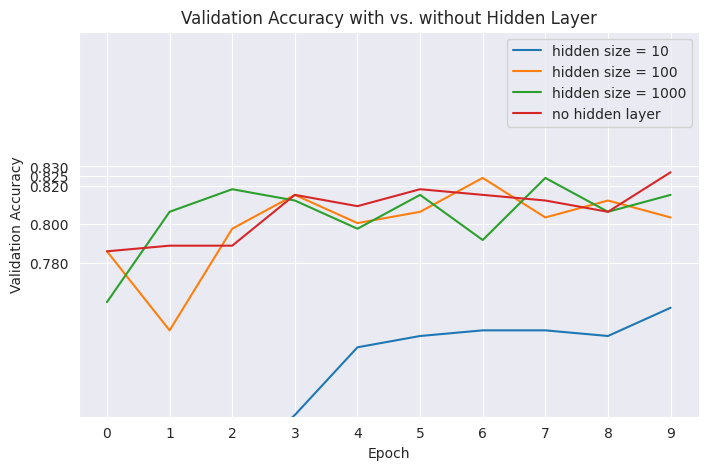

In [78]:

scores['none'] = scoresv1[0.001]
plt.figure(figsize=(8, 5))

for size, hist in scores.items():
    label = 'no hidden layer' if size == 'none' else f'hidden size = {size}'
    plt.plot(hist['val_accuracy'], label=label)

plt.title("Validation Accuracy with vs. without Hidden Layer")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.xticks(np.arange(10))
plt.yticks([0.78, 0.80, 0.82, 0.825, 0.83])
plt.ylim([0.7, 0.9])
plt.grid(True)
plt.legend()
plt.show()



## 📺 \[Session 8.9 – Dropout Regularization in Transfer Learning]

### ✅ Goal

The main objective of this session is to **prevent overfitting** in neural networks by introducing **dropout regularization**. The instructor demonstrates how to apply dropout after a newly added dense layer in a transfer learning model using Xception. The goal is to improve model generalization by ensuring it does not rely too heavily on specific image features (e.g., logos or background artifacts) that don't generalize across clothing classes.

---

### 🧠 Concept

**Dropout** is a regularization technique used to reduce overfitting in neural networks. During training, a percentage of neurons in a given layer are randomly "dropped out" (i.e., their outputs set to zero). This prevents the model from becoming too reliant on specific features and encourages it to learn more robust, generalized patterns.

In the context of this transfer learning setup (where Xception provides a frozen feature extractor), a dense layer is added after the global average pooling layer. Dropout is applied to this intermediate dense layer by specifying a `drop_rate` parameter. A drop rate of 0.2 means 20% of the neurons in that layer are randomly deactivated during each training iteration. This randomness helps the model avoid learning spurious correlations and improves its generalization to unseen validation data.

---

### 🧠 Key Points Learned Here

* Overfitting can occur when the model relies too heavily on specific image details (e.g., a brand logo or background).
* **Dropout** introduces noise during training by deactivating random parts of the network, forcing the model to rely on a broader set of features.
* Dropout is **only active during training**, not during inference.
* Dropout is applied **after the intermediate dense layer** in this setup, which is especially important since this is the only trainable part of the network.
* Experiments with dropout rates of 0.0, 0.2, and 0.8 show that:

  * **0.2 performed the best**, improving validation accuracy to \~84%.
  * **0.8 is too aggressive**, leading to worse performance or instability.
  * **0.0 (no regularization)** overfits fast and achieves high training accuracy, but lower validation performance.
* The benefit of dropout is sometimes **subtle** and needs to be evaluated alongside training/validation gap and overall stability.
* Regularization helps build **more trustworthy models**, even if the performance gain isn’t always large.

---

### 🛠️ Tasks

* Implemented a new model version with an intermediate dense layer (size=100).
* Added a `Dropout` layer after this intermediate layer, with a configurable `drop_rate` parameter.
* Trained models with different `drop_rate` values: `0.0`, `0.2`, and `0.8`.
* Extended training epochs from 10 to 30 to account for slower learning caused by dropout.
* Plotted and analyzed validation and training accuracy across configurations.
* Chose `drop_rate=0.2` as the best compromise between performance and regularization.



In [79]:
def make_model(learning_rate=0.01, size_inner=100, droprate=0.5):
    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(150, 150, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)

    outputs = keras.layers.Dense(10)(drop)

    model = keras.Model(inputs, outputs)

    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model

In [3]:
learning_rate = 0.001
size = 100

scores_v3 = {}

for droprate in [0.0, 0.2, 0.5, 0.8]:
    print(droprate)

    model = make_model(
        learning_rate=learning_rate,
        size_inner=size,
        droprate=droprate
    )

    history = model.fit(train_ds, epochs=30, validation_data=val_ds)
    scores_v3[droprate] = history.history

    print()
    print()

0.0


2025-07-17 15:43:53.302549: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-17 15:43:53.397060: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


NameError: name 'keras' is not defined

In [42]:
for droprate, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=('val=%s' % droprate))

plt.ylim(0.78, 0.86)
plt.legend()
plt.title("Validation Accuracy  with droprate")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

NameError: name 'scores' is not defined



## 📺 Session 8.11 – Training a Larger Model (Xception 299×299)

### ✅ Goal

The objective of this session is to **train a more accurate neural network** by scaling up the input image size from 150×150 to 299×299 and using the full capacity of the pre-trained Xception model. This transition aims to enhance model performance by leveraging more detailed features in higher-resolution images. Additionally, techniques like **data augmentation**, **dropout**, and **smaller learning rates** are re-evaluated to reduce overfitting and improve generalization on the validation set.

---

### 🧠 Concept

In earlier lessons, a smaller version of the Xception model was used (150×150 inputs) for faster experimentation. Here, the **full-resolution version (299×299)** is employed, allowing the convolutional layers to extract **richer, finer-grained features** from the input. However, this increases training time by about 4×.

The model uses **transfer learning** with frozen convolutional base and trains a classification head. To combat **overfitting**, **data augmentation** (e.g., zooming, flipping) and **dropout** are used. Additionally, a **smaller learning rate** is applied to stabilize training and reduce validation loss oscillations.

Checkpointing is introduced to save the best performing model based on validation accuracy. This larger model is expected to better capture intricate clothing features, increasing accuracy while preserving generalizability.

---

### 🧠 Key Points Learned Here

* **Larger images (299×299)** provide more information for the model but significantly increase computation time (\~4× slower per step).
* **Training accuracy** tends to grow quickly on large models, leading to potential overfitting if not regulated.
* **Data augmentation** (e.g., zoom, vertical flip) helps reduce overfitting by showing the model new variations of the same data at each epoch.
* **Validation accuracy** becomes more reliable with augmentation since the model no longer memorizes exact inputs.
* Adding **model checkpointing** is essential when training large models to avoid losing the best version.
* **Lower learning rates** smooth out the learning curve and prevent the model from diverging or oscillating during training.
* Even though augmentation increases CPU load and slows training, it can produce models that generalize better and have lower validation gaps.

---

### 🛠️ Tasks

* Modified the `input_size` parameter to allow flexible resolution (299×299 for Xception).
* Reused and adapted the model code from previous sessions with added configurability.
* Integrated **data augmentation** (zoom range, vertical flip) into the training pipeline.
* Enabled **model checkpointing** to store the best-performing model.
* Switched between augmentation on/off to assess impact on validation accuracy.
* Compared training/validation accuracies with and without augmentation.
* Reduced the **learning rate** to smooth the training process and improve generalization.
* Evaluated overfitting risk by analyzing accuracy gaps and confirmed that **augmented models** yielded more reliable results.



In [13]:
def make_model(input_size=150, learning_rate=0.01, size_inner=100,
               droprate=0.5):

    base_model = Xception(
        weights='imagenet',
        include_top=False,
        input_shape=(input_size, input_size, 3)
    )

    base_model.trainable = False

    #########################################

    inputs = keras.Input(shape=(input_size, input_size, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)

    inner = keras.layers.Dense(size_inner, activation='relu')(vectors)
    drop = keras.layers.Dropout(droprate)(inner)

    outputs = keras.layers.Dense(10)(drop)

    model = keras.Model(inputs, outputs)

    #########################################

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.CategoricalCrossentropy(from_logits=True)

    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    return model


input_size = 299
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

train_ds = train_gen.flow_from_directory(
    '../Data/clothing-dataset-small/train',
    target_size=(input_size, input_size),
    batch_size=32
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = train_gen.flow_from_directory(
    '../Data/clothing-dataset-small/validation',
    target_size=(input_size, input_size),
    batch_size=32,
    shuffle=False
)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [14]:
checkpoint = keras.callbacks.ModelCheckpoint(
    'xception_v4_1_{epoch:02d}_{val_accuracy:.3f}.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max'
)

In [38]:
learning_rate = 0.001
size = 100
droprate = 0.2

model = make_model(
    input_size=input_size,
    learning_rate=learning_rate,
    size_inner=size,
    droprate=droprate
)

history = model.fit(train_ds, epochs=10, validation_data=val_ds,
                   callbacks=[checkpoint])

Epoch 1/10
96/96 [==============================] - 262s 3s/step - loss: 0.8273 - accuracy: 0.7275 - val_loss: 0.4751 - val_accuracy: 0.8446
Epoch 2/10
96/96 [==============================] - 257s 3s/step - loss: 0.4588 - accuracy: 0.8377 - val_loss: 0.4211 - val_accuracy: 0.8446
Epoch 3/10
96/96 [==============================] - 265s 3s/step - loss: 0.3854 - accuracy: 0.8628 - val_loss: 0.3781 - val_accuracy: 0.8739
Epoch 4/10
96/96 [==============================] - 270s 3s/step - loss: 0.3164 - accuracy: 0.8931 - val_loss: 0.3851 - val_accuracy: 0.8739
Epoch 5/10
96/96 [==============================] - 183s 2s/step - loss: 0.2962 - accuracy: 0.8944 - val_loss: 0.3659 - val_accuracy: 0.8768
Epoch 6/10
96/96 [==============================] - 164s 2s/step - loss: 0.2624 - accuracy: 0.9068 - val_loss: 0.3962 - val_accuracy: 0.8710
Epoch 7/10
96/96 [==============================] - 160s 2s/step - loss: 0.2533 - accuracy: 0.9097 - val_loss: 0.3527 - val_accuracy: 0.8915
Epoch 8/10
96

Text(0, 0.5, 'Validation Accuracy')

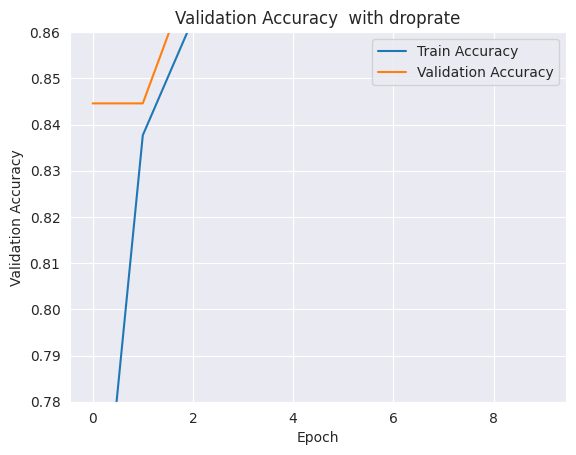

In [39]:

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.ylim(0.78, 0.95)
plt.legend()
plt.title("Validation Accuracy  with droprate")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")


## 📺 Session 8.12 – Model Evaluation & Prediction

### ✅ Goal

The objective of this session is to **evaluate the performance of the final trained model on a separate test dataset** and demonstrate how to **load the model and use it to make predictions** on individual images. This confirms whether the model generalizes well and provides a practical example of how to use a trained model in real-world applications like clothing classification. The session also includes post-processing the output logits to determine the predicted class.

---

### 🧠 Concept

After training a high-performing convolutional neural network (based on the Xception architecture with 299×299 input size), it is essential to **validate its performance on unseen test data**. This is done by loading the saved model checkpoint and applying it to the test dataset using the `.evaluate()` method, which returns both the loss and accuracy. Furthermore, this session introduces the process of making **individual predictions** on images by loading an image, resizing it, converting it to a NumPy array, applying the correct preprocessing function, and then passing it through the model using `.predict()`. The resulting logits (unnormalized scores) are mapped to class labels, and the top prediction is extracted to interpret the result. This full pipeline simulates a production use-case for image classification.

---

### 🧠 Key Points Learned Here

* **Model Loading**: The model trained and saved in the previous session is loaded using `keras.models.load_model()`.
* **Test Evaluation**: Using `.evaluate()`, we assess test performance, confirming the model has not overfit (test accuracy \~90%).
* **Image Preprocessing**: New images must be resized (299×299), converted to arrays, and passed through the same preprocessing pipeline used during training (`preprocess_input` from Xception).
* **Prediction Pipeline**: After preprocessing, the image is passed through the model with `.predict()`, yielding **logits** for each class.
* **Interpreting Results**: Logits are matched to class labels using `zip()` and converted to a dictionary for readability. Although not converted to probabilities, the relative values indicate class likelihoods.
* **Correct Classification**: The model correctly classifies a test image (e.g., pants), showing strong performance and robustness.
* **Practical Readiness**: This session bridges training and real-world usage, showing how to package a trained model into a functional prediction tool.

---

### 🛠️ Tasks

* Loaded a pre-trained model using `keras.models.load_model("model_name")`
* Loaded and prepared the test dataset (ImageDataGenerator + `flow_from_directory`)
* Evaluated the model on the test dataset using `.evaluate()`
* Loaded a single image with `load_img()` and resized it to 299×299
* Converted the image to a NumPy array and applied Xception preprocessing
* Used `.predict()` to obtain logits from the model
* Created a mapping between predicted scores and class labels using `zip()` and dictionary construction
* Interpreted and displayed the top prediction
* Verified the model generalizes well to unseen images

In [45]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import load_img

from tensorflow.keras.applications.xception import preprocess_input

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_ds = test_gen.flow_from_directory(
    '../Data/clothing-dataset-small/test',
    target_size=(299, 299),
    batch_size=32,
    shuffle=False
)
model = keras.models.load_model('../Data/xception_v4_1_04_0.862.h5')


Found 372 images belonging to 10 classes.


TypeError: Error when deserializing class 'SeparableConv2D' using config={'name': 'block2_sepconv1', 'trainable': False, 'dtype': 'float32', 'filters': 128, 'kernel_size': [3, 3], 'strides': [1, 1], 'padding': 'same', 'data_format': 'channels_last', 'dilation_rate': [1, 1], 'groups': 1, 'activation': 'linear', 'use_bias': False, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None, 'depth_multiplier': 1, 'depthwise_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'pointwise_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 

In [46]:
model.evaluate(test_ds)


12/12 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.7984 - loss: 0.7135


[0.7134567499160767, 0.7983871102333069]

In [47]:
path = '../Data/clothing-dataset-small/test/pants/c8d21106-bbdb-4e8d-83e4-bf3d14e54c16.jpg'
img = load_img(path, target_size=(299, 299))
import numpy as np

x = np.array(img)
X = np.array([x])
X.shape
X = preprocess_input(X)
pred = model.predict(X)
pred.shape
print(pred)

ValueError: Input 0 of layer "functional_5" is incompatible with the layer: expected shape=(None, 150, 150, 3), found shape=(1, 299, 299, 3)

In [38]:
predicted_class = np.argmax(pred)

print(pred,predicted_class)
name_pred = {v: k for k, v in train_ds.class_indices.items()}[np.argmax(pred)]
import matplotlib.pyplot as plt

# De-normalize if needed (optional: for better visualization)
# If preprocess_input scaled from [0, 255] → [-1, 1], reverse it:
# img = (X + 1) * 127.5 / 255.0  # now values are in [0, 1] range

# Plot the image
img = load_img(path, target_size=(299, 299))
plt.imshow(img)
plt.axis('off')
plt.title(f"Image corresponding to preds[{img_num}]-> {name_pred} ")
plt.show()

[[3.23712360e-04 1.57383998e-04 2.13493448e-04 1.52370674e-04
  2.47626536e-04 3.05036345e-04 3.20592633e-04 1.47499464e-04
  2.03622069e-04 1.49272586e-04 1.95663306e-04 2.10137645e-04
  7.59265822e-05 1.13972354e-04 1.62683718e-04 2.04638840e-04
  1.97416171e-04 1.44289035e-04 1.40217642e-04 1.73686160e-04
  7.46691134e-04 2.56966945e-04 2.66809162e-04 2.96514685e-04
  3.73602554e-04 2.77404557e-04 2.16571294e-04 2.27270401e-04
  3.80813202e-04 1.72166154e-04 3.05401365e-04 1.96431545e-04
  3.92115413e-04 4.78071976e-04 2.91751785e-04 3.25693720e-04
  1.47395403e-04 1.62362267e-04 2.12710802e-04 1.34028407e-04
  2.40070905e-04 6.75212650e-04 2.54943880e-04 1.44478909e-04
  4.12821624e-04 2.04408891e-04 3.02958535e-04 1.49339787e-04
  1.99653950e-04 2.27006123e-04 2.93729478e-04 2.27444936e-04
  6.37645135e-04 7.82616611e-04 2.49557605e-04 4.05271101e-04
  2.98437721e-04 1.94578621e-04 4.18178475e-04 4.46841092e-04
  1.89225873e-04 2.20415459e-04 1.66704223e-04 9.56101867e-05
  4.4334

KeyError: np.int64(610)


## 📺 Session 8.13 – Summary of Image Classification with CNNs

### ✅ Goal

The goal of this final session is to **summarize everything learned in Session 8** of the ML Zoomcamp, which focused on solving an image classification task using convolutional neural networks (CNNs). The case study involved building a web-based system where a user uploads an image of a clothing item, and the system predicts its category among 10 predefined classes. Throughout the session, learners explored data loading, transfer learning, architecture tuning, regularization techniques, model evaluation, and prediction pipelines. This session also introduces **ideas for further exploration**, such as alternative model architectures, augmentation libraries, new datasets, and using frameworks like PyTorch. It aims to consolidate understanding and open doors to more advanced experimentation or deployment scenarios.

---

### 🧠 Concept

This session wraps up the process of applying deep learning to image classification using **Keras and TensorFlow**. The core idea was to **leverage transfer learning** by using a pre-trained CNN (Xception) as a fixed feature extractor and customizing the output layers to fit a new classification task. The pipeline included data preprocessing, model construction, tuning hyperparameters (like learning rate and dense layer size), and implementing regularization through dropout and data augmentation.

The model was evaluated on separate validation and test sets, confirming it generalized well (\~90% accuracy). Students also learned how to apply the trained model to individual images for real-world inference. Beyond training, the session highlighted **practical enhancements**: experimenting with other CNN architectures (e.g., ResNet, MobileNet), trying other deep learning libraries (PyTorch, MXNet), and using creative datasets (e.g., hotdog vs. not hotdog). The session bridges theoretical understanding, practical implementation, and ideas for real-world deployment.

---

### 🧠 Key Points Learned Here

* **Project Overview**: Classify uploaded clothing images into 10 categories using a convolutional neural network.
* **Frameworks Used**: Built the pipeline using TensorFlow and Keras, abstracting away low-level operations to focus on high-level design.
* **Transfer Learning**: Reused a pre-trained Xception model trained on ImageNet. Retained convolutional layers and replaced the classifier head.
* **Model Tuning**:

  * Explored different **learning rates** (fast vs. stable convergence).
  * Added **intermediate dense layers** to learn richer representations.
  * Used **dropout** to reduce overfitting by randomly deactivating neurons during training.
  * Applied **data augmentation** to generate synthetic image variations and improve generalization.
* **Training Strategy**:

  * Started with 150×150 images for fast prototyping.
  * Finished with full-size 299×299 images for final model training.
  * Used **checkpointing** to save the best model automatically.
* **Evaluation**:

  * Achieved 90% accuracy on both validation and test datasets.
  * Validated the model on unseen data to confirm robustness.
* **Prediction Pipeline**:

  * Loaded external images.
  * Preprocessed them identically to training data.
  * Passed through the model and decoded the logits to get predicted classes.
* **Next Steps Suggested**:

  * Try other architectures: MobileNet (faster), ResNet50 (lighter), Inception-ResNet (more accurate but slow).
  * Use different frameworks (e.g., PyTorch).
  * Experiment with other datasets like hotdog/not hotdog, Avito classifieds.
  * Use augmentation libraries like **Albumentations** for more advanced transforms.
